# Germany Population Prediction 🇩🇪

A simple time series forecasting project to predict the population of Germany using the **Holt-Winters Exponential Smoothing** model.

## 📊 Dataset

The dataset contains Germany's population from **1950 to 2025** with two columns:

- `Year`
- `Population`

## 🔮 Prediction

The **Holt-Winters model** is trained on the historical population data and used to forecast Germany's population for:

- **2026**
- to
- **2030**

## 🛠️ Technologies

- Python
- Pandas
- Matplotlib
- Statsmodels

## 📈 Model

**Holt-Winters Exponential Smoothing**

The model learns the historical trend in Germany's population and uses it to generate future forecasts.

## 🎯 Goal

The goal of this project is to demonstrate a simple **time series forecasting workflow** using historical population data.

```
Import the key libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# the table is alittle messy, we need to correctly read it

df = pd.read_csv('Germany_Population.csv',
                sep=';',
                skiprows=5,
                encoding='utf-8-sig',
                header=None)

df.columns = ['Date','Population','status']
df = df.dropna(subset=['Date','Population'])

In [42]:
df.head()

,Date,Population,status
1,1950-12-31,50958125,e
2,1951-12-31,51434777,e
3,1952-12-31,51863761,e
4,1953-12-31,52453806,e
5,1954-12-31,52943295,e


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76 entries, 1 to 76
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        76 non-null     object
 1   Population  76 non-null     object
 2   status      76 non-null     object
dtypes: object(3)
memory usage: 2.4+ KB


In [44]:
df['Date'] = pd.to_datetime(df['Date'])
df['Population'] = pd.to_numeric(df['Population'])

In [45]:
df = df.set_index('Date')

In [46]:
df.head()

,Population,status
Date,,
1950-12-31,50958125,e
1951-12-31,51434777,e
1952-12-31,51863761,e
1953-12-31,52453806,e
1954-12-31,52943295,e


In [47]:
df.drop('status', axis=1, inplace=True)

In [48]:
df

,Population
Date,
1950-12-31,50958125
1951-12-31,51434777
1952-12-31,51863761
1953-12-31,52453806
1954-12-31,52943295
...,...
2021-12-31,83237124
2022-12-31,83118501
2023-12-31,83456045


In [49]:
df.index.freq = 'YE' # we set the freq to the end of the year

In [50]:
df.to_csv('cleaned_data_germany_population_1950-25.csv')

```
Now we have the clean dataset

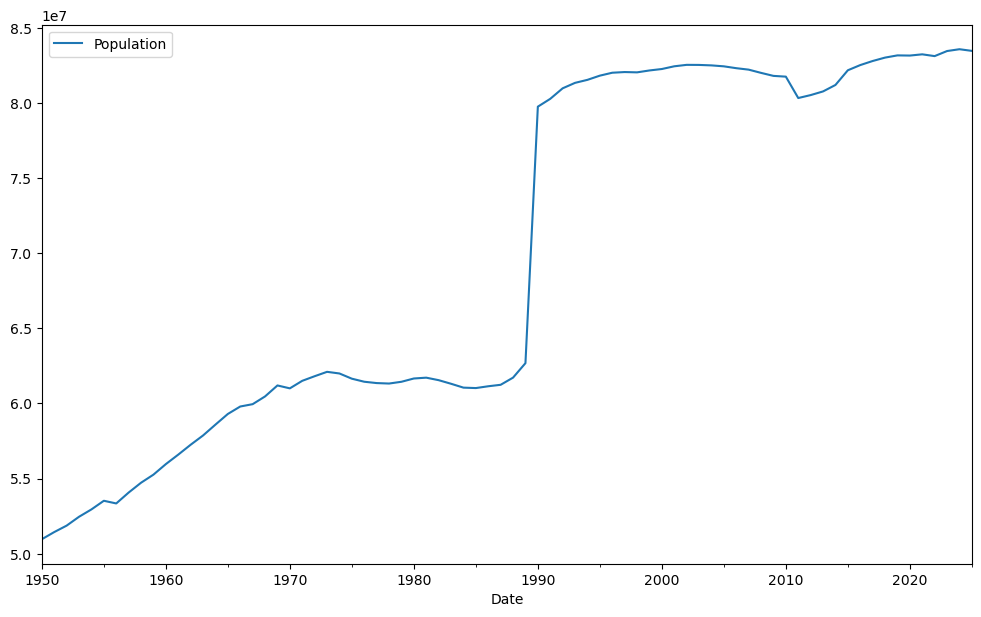

In [52]:
df.plot(figsize=(12,7));

```
As we can see, the population increased sharply toward the end of the 20th century and then continued to grow gradually at a slower rate.

In [84]:
len(df)

76

In [85]:
train = df.iloc[:71]
test = df.iloc[71:]

In [86]:
from statsmodels.tsa.ar_model import AutoReg, ARResults

In [87]:
import warnings 
warnings.filterwarnings('ignore')

In [88]:
start = len(train)
end = len(train) + len(test) -1

In [89]:
model = AutoReg(train['Population'], lags=1).fit()

In [90]:
model.params

const            1.890248e+06
Population.L1    9.791564e-01
dtype: float64

In [91]:
preds = model.predict(start=start, end=end)

In [92]:
preds

2021-12-31    8.331203e+07
2022-12-31    8.346576e+07
2023-12-31    8.361628e+07
2024-12-31    8.376367e+07
2025-12-31    8.390798e+07
Freq: YE-DEC, dtype: float64

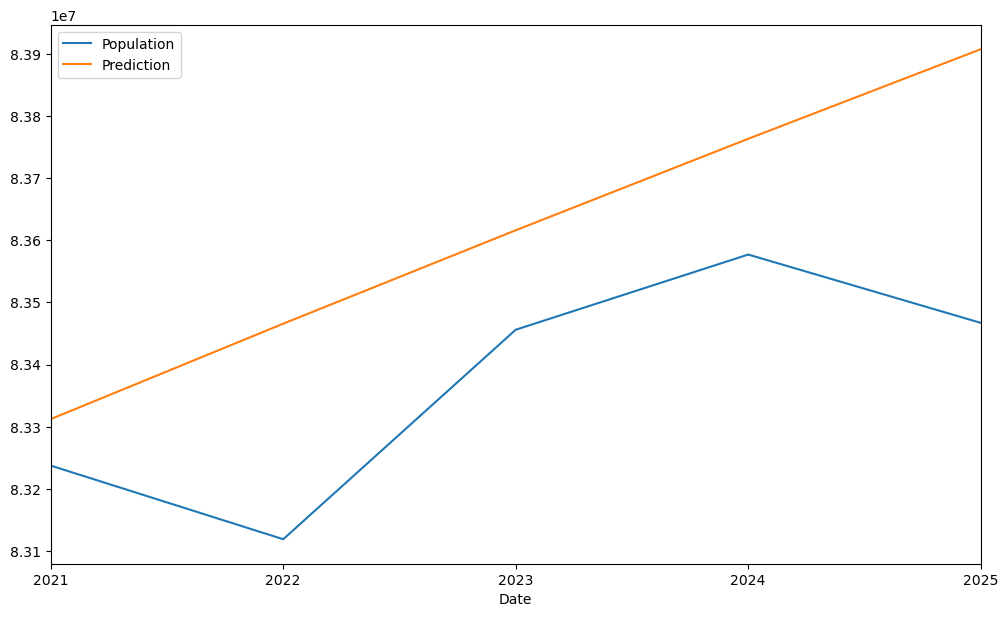

In [93]:
test['Population'].plot(legend=True, figsize=(12,7))
preds.plot(legend=True, label='Prediction');

In [74]:
from sklearn.metrics import mean_absolute_error, r2_score , mean_squared_error

In [82]:
mean_absolute_error(test,preds)

241959.04453725516

In [73]:
test.mean()

Population    83371185.4
dtype: float64

```
Not bad as a result.

let's test another legs num.

In [95]:
model_2 = AutoReg(train['Population'], lags=2).fit()

In [96]:
model_2.params

const            1.956949e+06
Population.L1    1.047997e+00
Population.L2   -7.021093e-02
dtype: float64

In [97]:
preds_2 = model_2.predict(start,end)

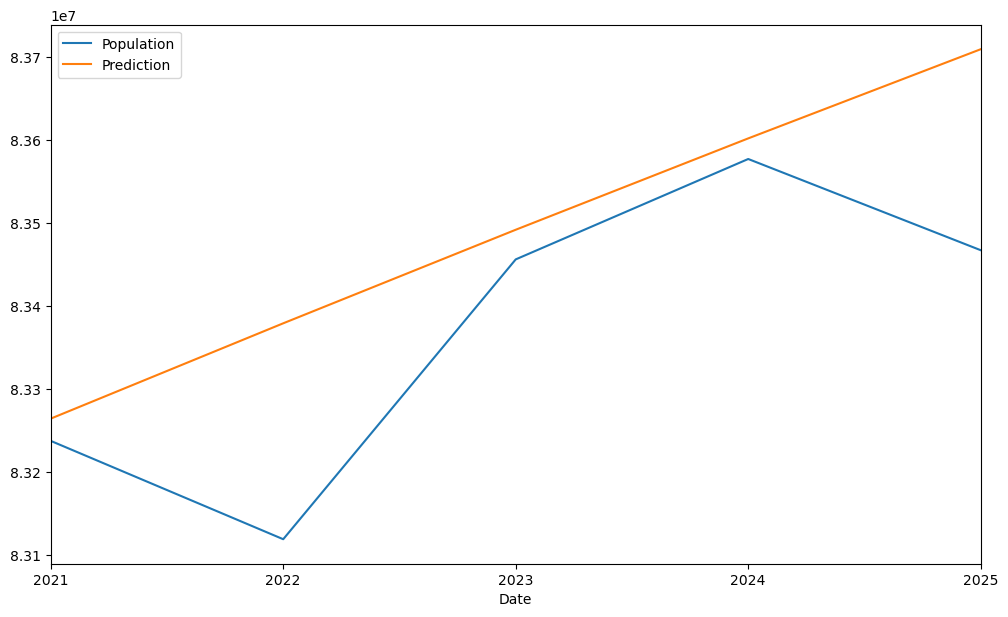

In [101]:
test.plot(legend=True, figsize=(12,7))
preds_2.plot(legend=True, label='Prediction');

In [100]:
mean_absolute_error(test,preds_2)

118066.35820600689

```
still not good, let's feed our model the data from 1990 or the sharp increase, so we may predict a better result.

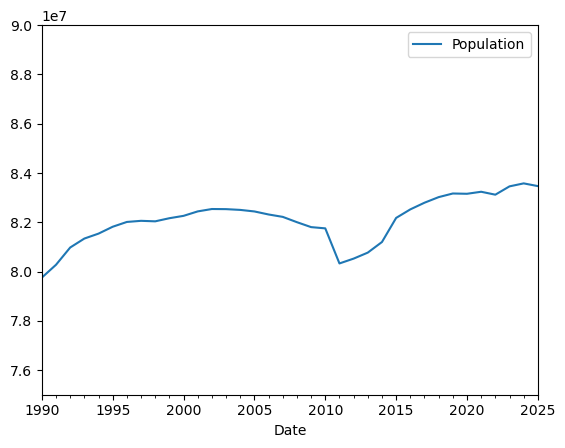

In [115]:
df.plot(xlim=('1990-10-1','2025-01-01'), ylim=(75000000,90000000));

In [124]:
df_1990 = df.loc['1990-01-01':]

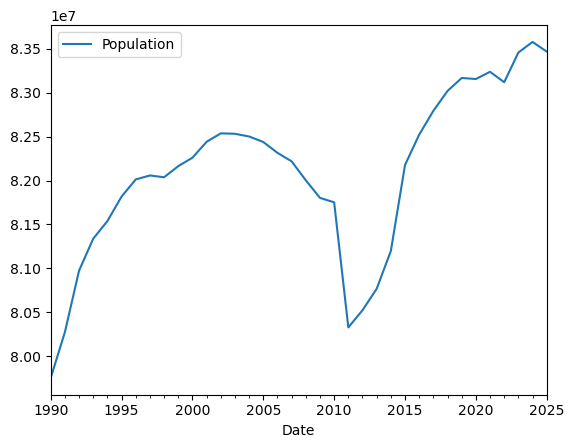

In [127]:
df_1990.plot();

In [128]:
len(df_1990)

36

In [129]:
train = df_1990.iloc[:31]
test = df_1990.iloc[31:]

In [130]:
reg_model = AutoReg(train['Population'], lags=2).fit()

In [131]:
start = len(train)
end = len(train) + len(test) -1

In [132]:
predictions = reg_model.predict(start, end)

In [133]:
predictions

2021-12-31    8.296917e+07
2022-12-31    8.275238e+07
2023-12-31    8.256505e+07
2024-12-31    8.242454e+07
2025-12-31    8.232855e+07
Freq: YE-DEC, dtype: float64

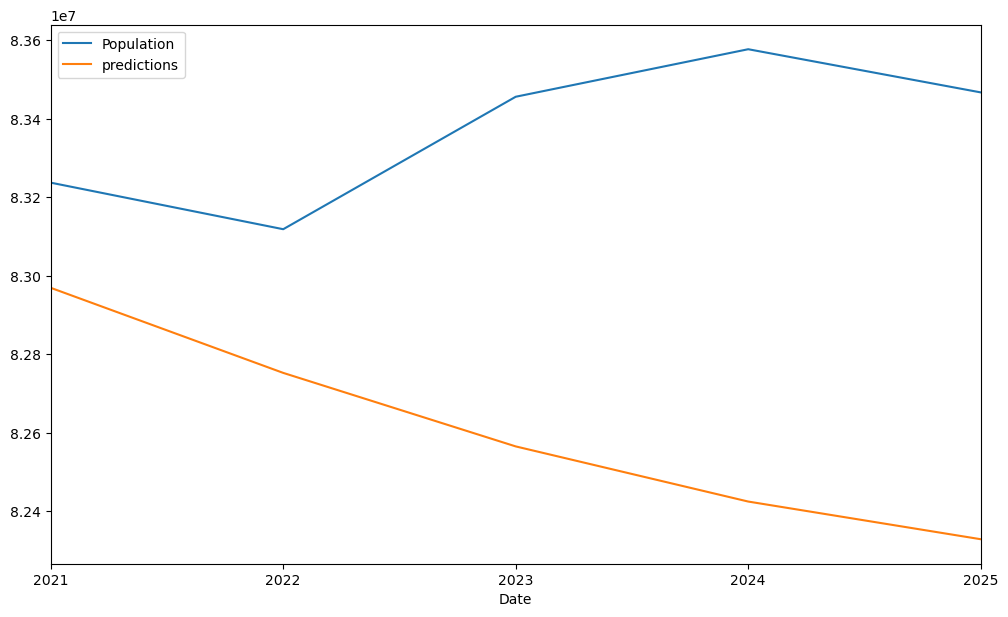

In [143]:
test['Population'].plot(legend=True, figsize=(12,7))
predictions.plot(legend=True, label='predictions');

In [135]:
# choosing the best lags

from statsmodels.tsa.ar_model import ar_select_order

In [138]:
sel = ar_select_order(train['Population'], maxlag=12, ic='bic')
new_model = AutoReg(train['Population'], lags=sel.ar_lags).fit()

In [139]:
new_preds = new_model.predict(start,end)

In [140]:
new_preds

2021-12-31    8.303715e+07
2022-12-31    8.294002e+07
2023-12-31    8.286001e+07
2024-12-31    8.279408e+07
2025-12-31    8.273977e+07
Freq: YE-DEC, dtype: float64

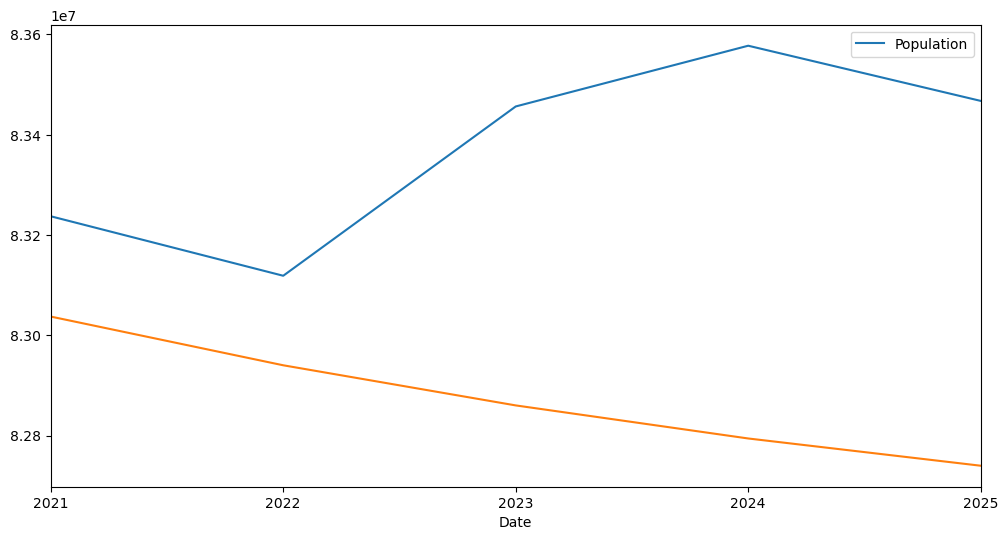

In [152]:
test.plot(legend=True, figsize=(12,6))
new_preds.plot();

In [142]:
new_model.params

const            1.452718e+07
Population.L1    8.238825e-01
dtype: float64

```
Let's apply a Holt_Winters model

In [147]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [168]:
h_model = ExponentialSmoothing(train['Population'],
                              trend='add',
                              seasonal='add',
                              seasonal_periods=4).fit()

In [169]:
h_preds = h_model.forecast(5)

In [170]:
h_preds

2021-12-31    8.323421e+07
2022-12-31    8.329665e+07
2023-12-31    8.336242e+07
2024-12-31    8.350668e+07
2025-12-31    8.358586e+07
Freq: YE-DEC, dtype: float64

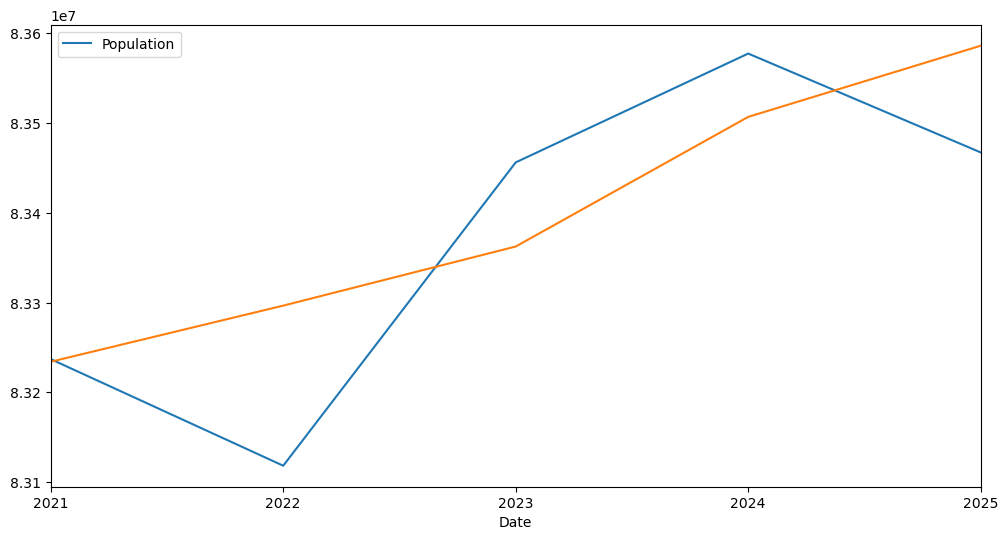

In [171]:
test['Population'].plot(legend=True, figsize=(12,6))
h_preds.plot(label='Forecast');

In [172]:
mean_absolute_error(test,h_preds)

92777.70238308012

In [173]:
preds_2030 = h_model.forecast(10)

In [176]:
preds_2030 = preds_2030[5:]

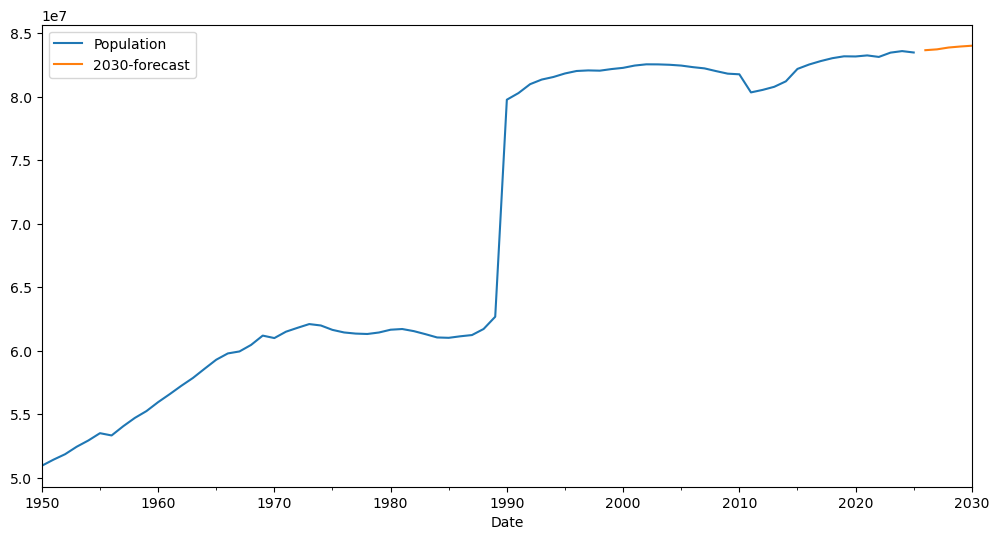

In [182]:
df.plot(figsize=(12,6))
preds_2030.plot(label='2030-forecast', legend=True);

# Well done